Module importing

In [5]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from unet_base_1D import unet_base_1D
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_13684\2803335453.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})


254
torch.Size([1, 800])


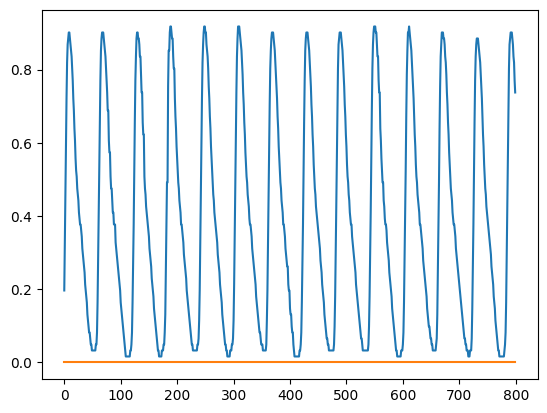

In [6]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [7]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         800,
        "Input size":           1,
        "Encoder structure":    [1, 64, 128, 256, 512],
        "Decoder structure":    [512, 256, 128, 64, 100],
        "Kernel size":          [3] * 9,
        "Stride":               [2, 2, 2, 2],
        "Activate function":    nn.GELU()
    }
    

model = unet_base_1D(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=1500,batch=64,visualize=1)

True
Iteration: 1/1500. loss_train: 0.23159344494342804. loss_val: 0
Iteration: 2/1500. loss_train: 0.16055843234062195. loss_val: 0
Iteration: 3/1500. loss_train: 0.12357894331216812. loss_val: 0
Iteration: 4/1500. loss_train: 0.10060474276542664. loss_val: 0
Iteration: 5/1500. loss_train: 0.08655169606208801. loss_val: 0
Iteration: 6/1500. loss_train: 0.07814161479473114. loss_val: 0
Iteration: 7/1500. loss_train: 0.07231983542442322. loss_val: 0
Iteration: 8/1500. loss_train: 0.06888476014137268. loss_val: 0
Iteration: 9/1500. loss_train: 0.06646254658699036. loss_val: 0
Iteration: 10/1500. loss_train: 0.06313835084438324. loss_val: 0
Iteration: 11/1500. loss_train: 0.06178151071071625. loss_val: 0
Iteration: 12/1500. loss_train: 0.05974675714969635. loss_val: 0
Iteration: 13/1500. loss_train: 0.05691755563020706. loss_val: 0
Iteration: 14/1500. loss_train: 0.05374625697731972. loss_val: 0
Iteration: 15/1500. loss_train: 0.05047336220741272. loss_val: 0
Iteration: 16/1500. loss_trai

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_13684\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  1.0000085
Mean loss:  0.26757282
Min loss:  0.0004803182
Number of test:  84


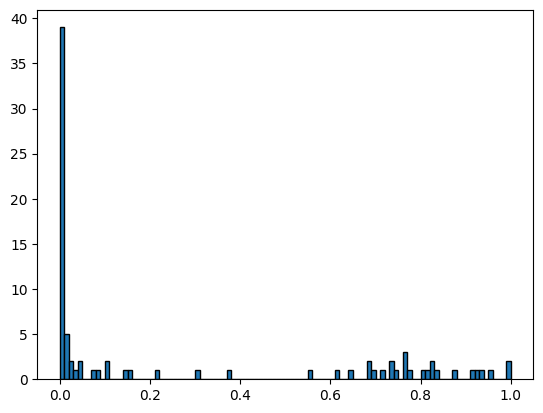

0.15611976


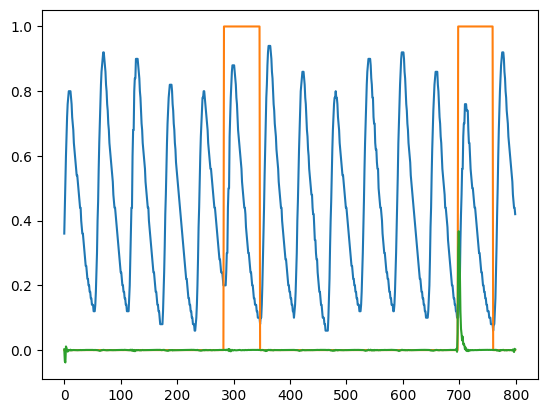

0.68886006


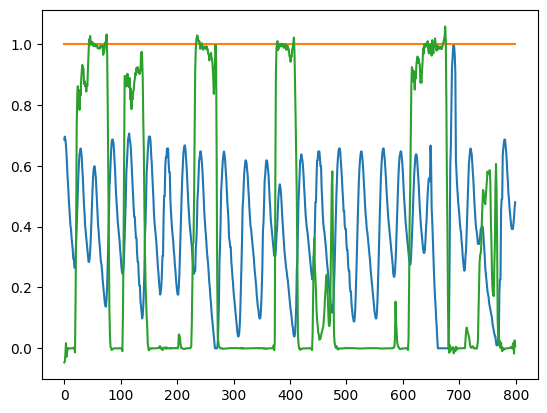

0.76461715


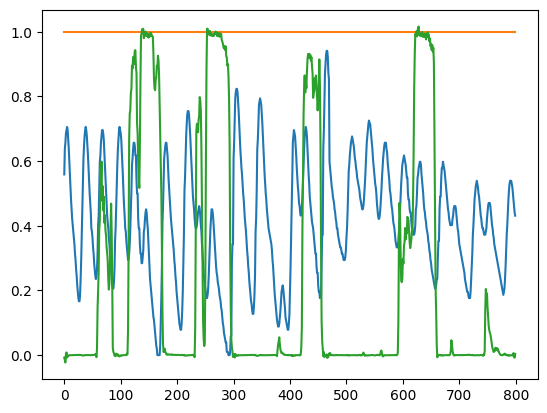

0.00065358006


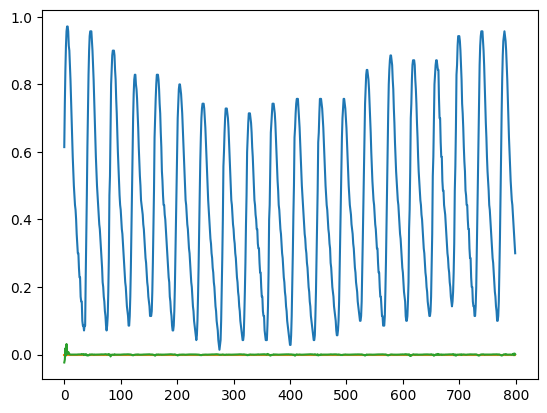

0.0007214389


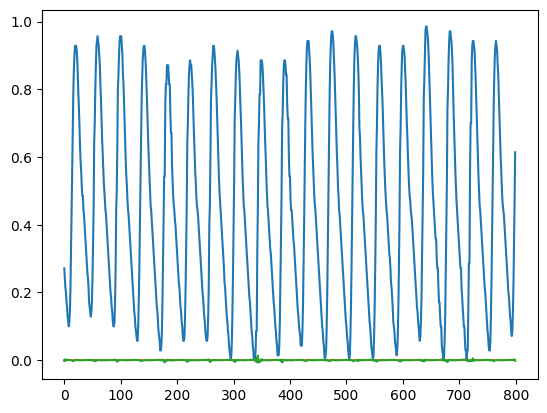

0.00071742834


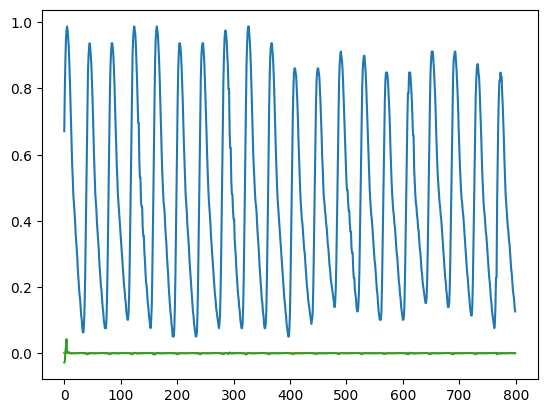

0.00076163333


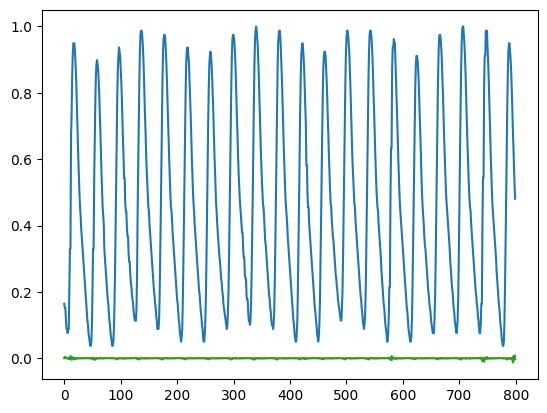

0.0006602767


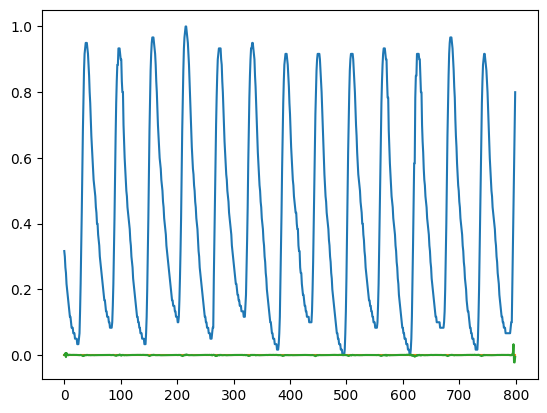

0.0005197585


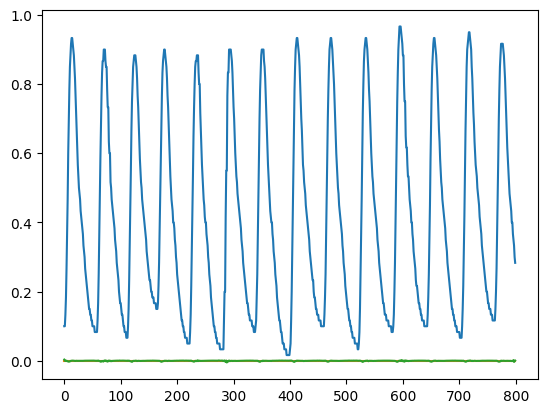

0.0005525674


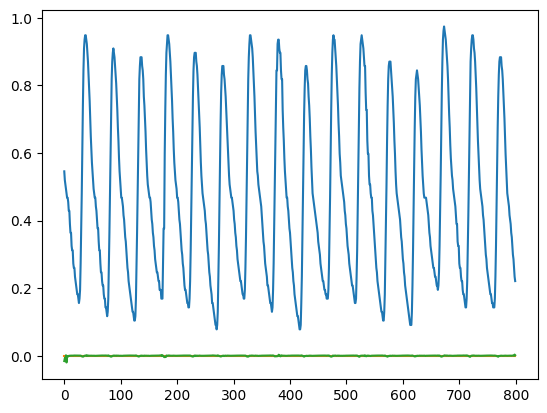

0.000541616


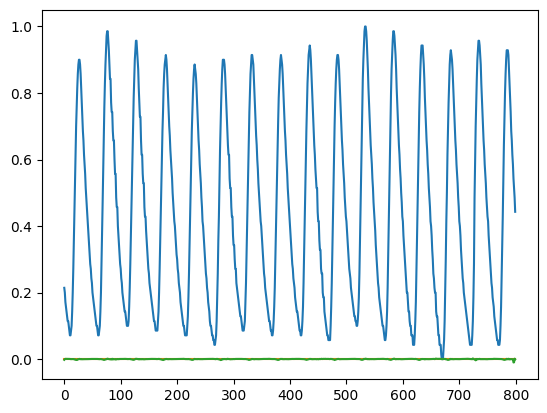

0.0004803182


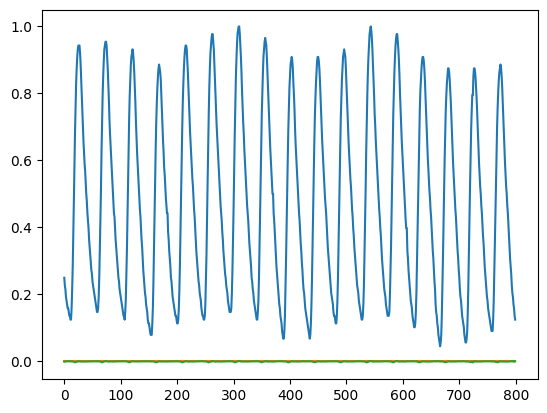

0.008950417


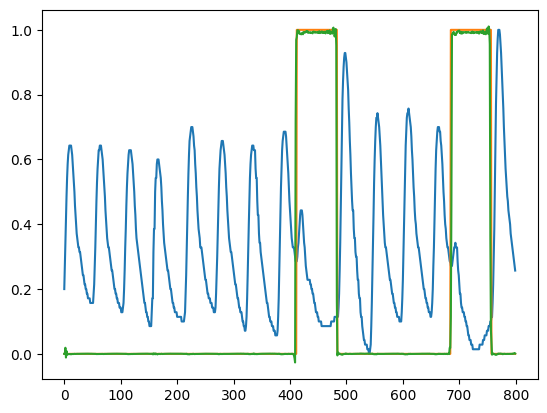

0.08241294


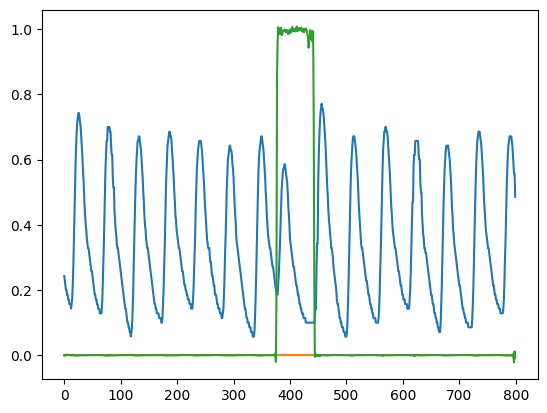

0.049533375


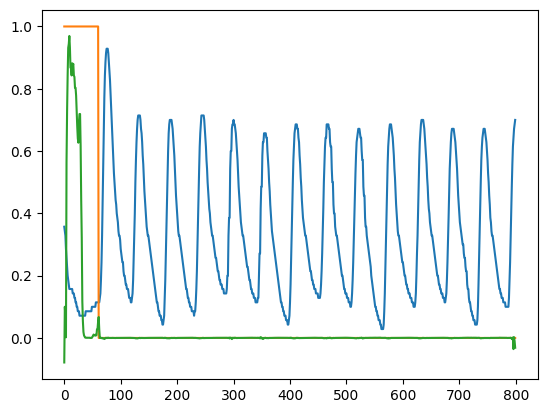

0.0005967243


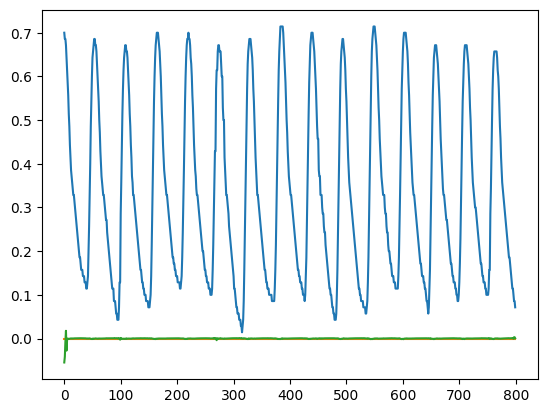

0.8796995


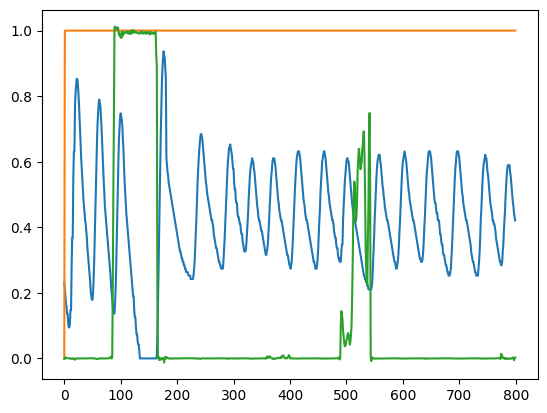

0.9319767


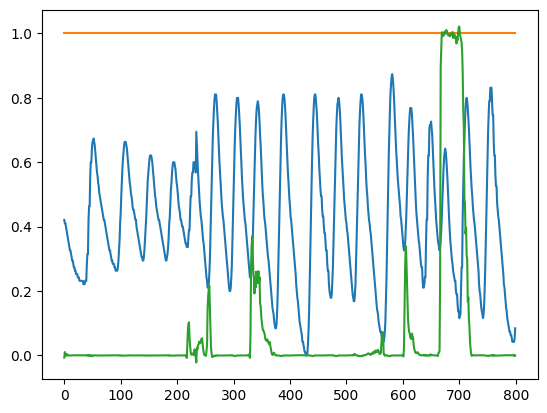

0.8279779


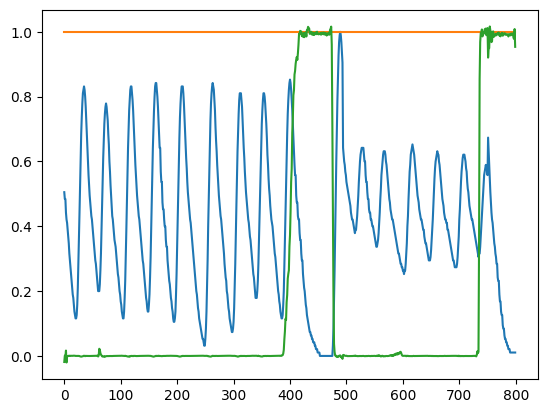

0.80681556


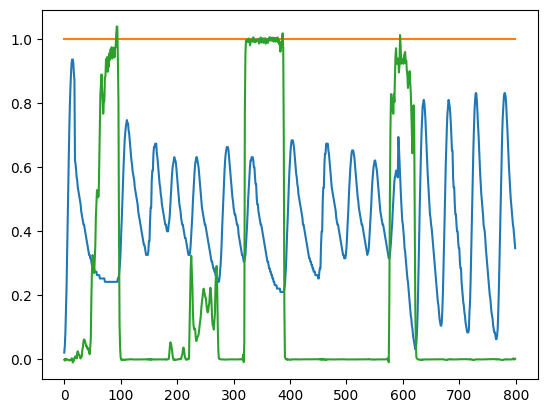

0.9157819


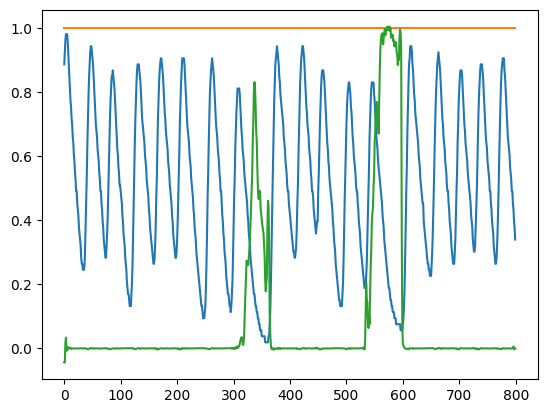

0.0005350238


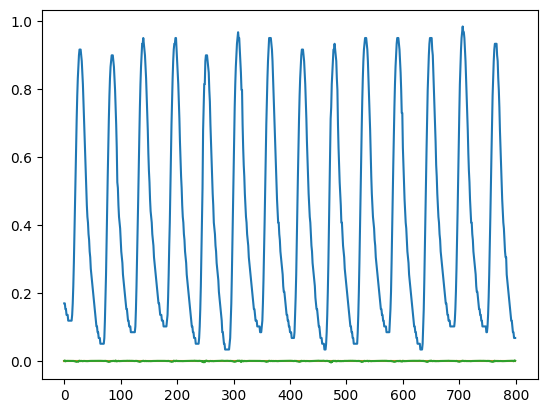

0.0005182696


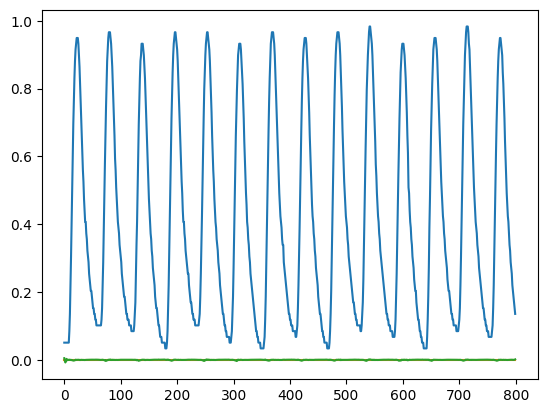

0.0005255794


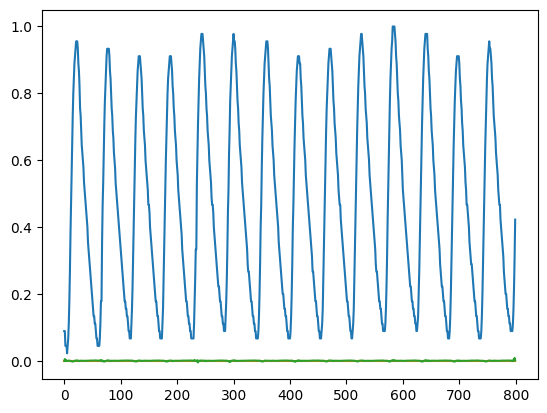

0.0005377874


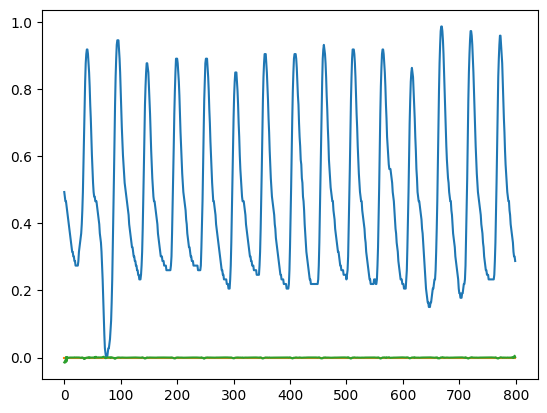

0.0012212422


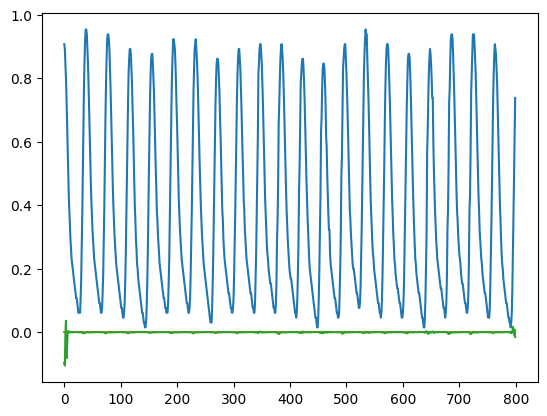

0.7685205


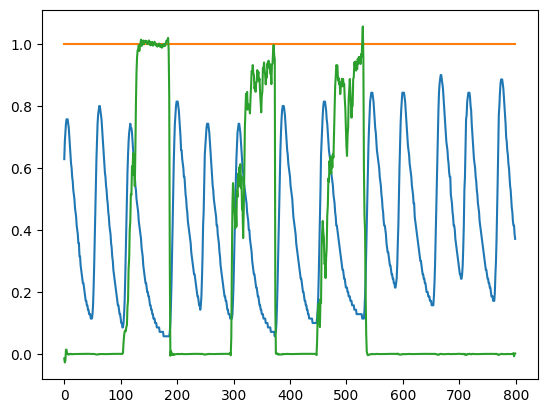

0.0007622303


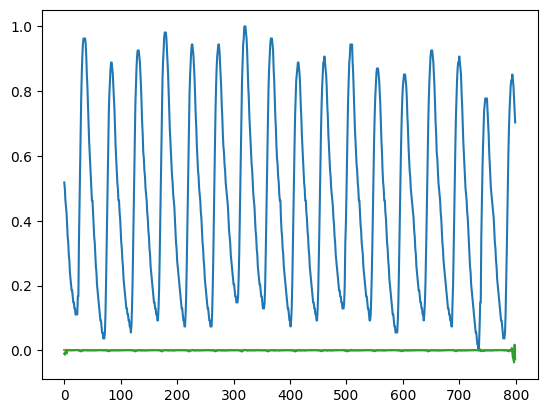

0.00078427594


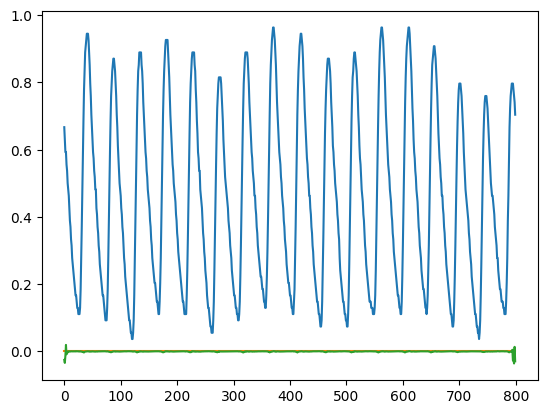

0.64433926


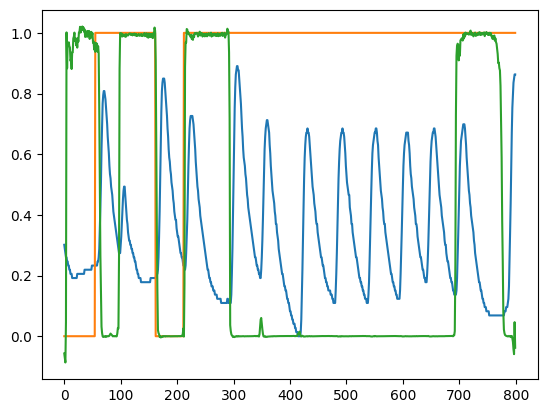

0.0006933207


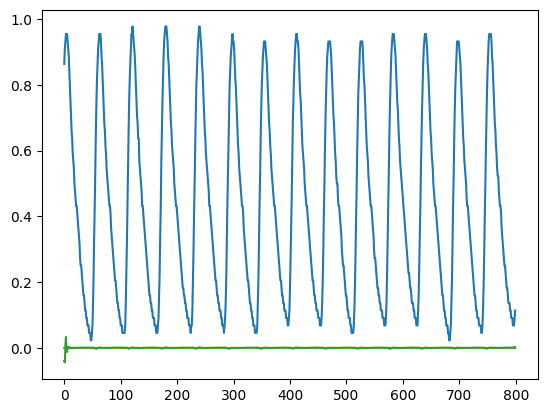

0.00053405814


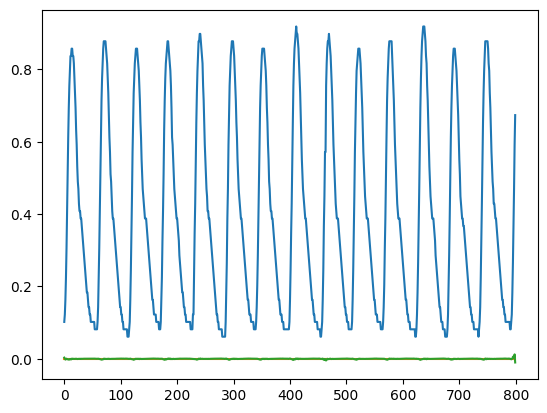

0.0009214097


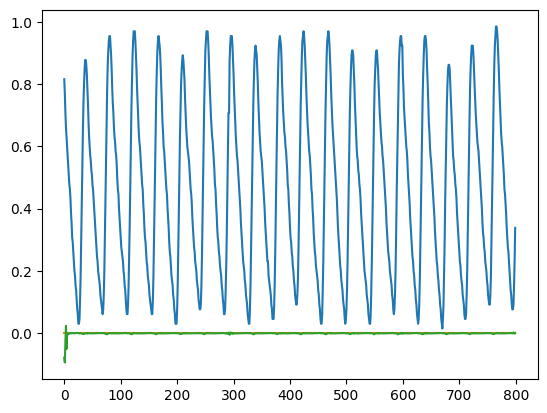

0.0008287166


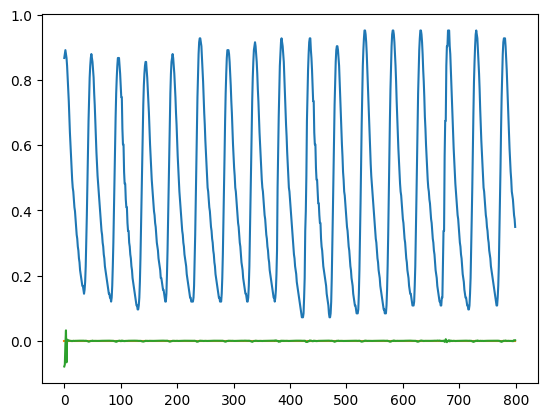

0.0005303026


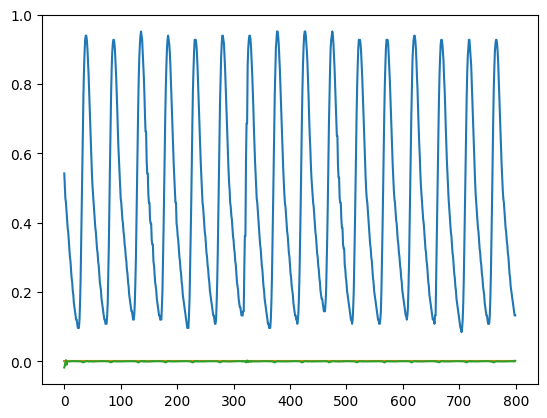

0.0007399829


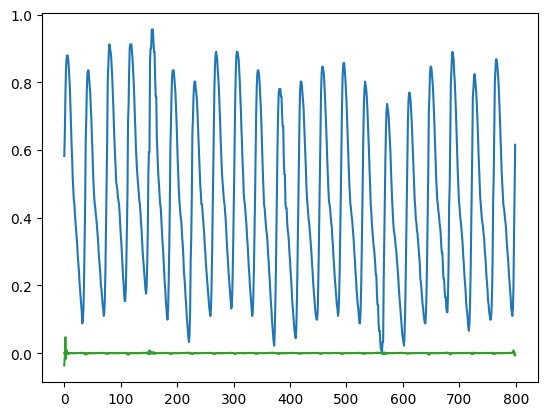

0.00059792947


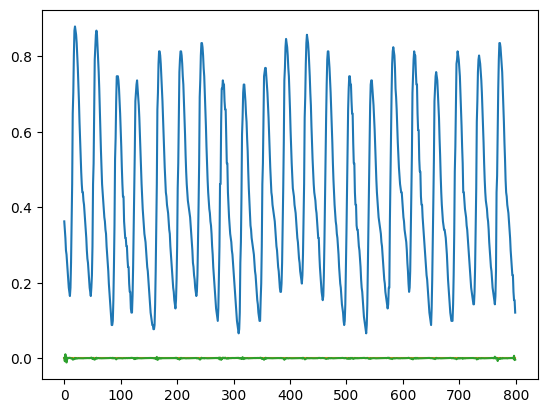

0.0005204164


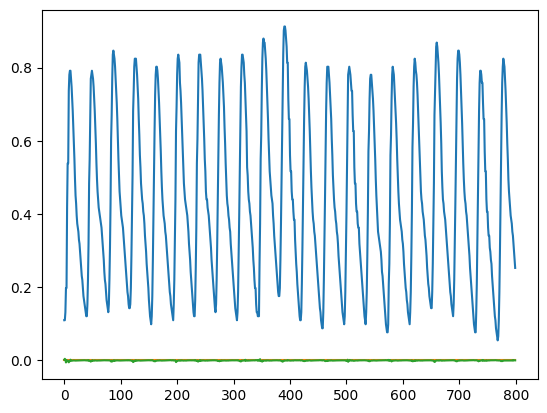

0.0007356255


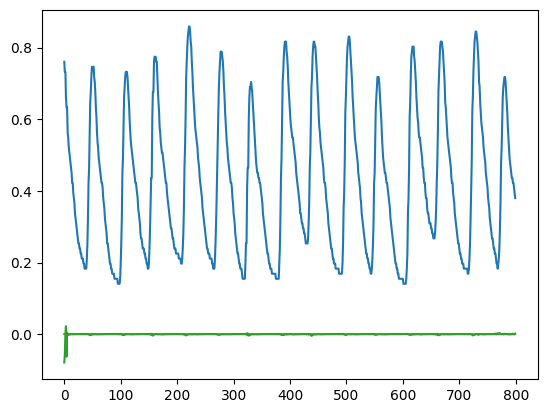

0.7662514


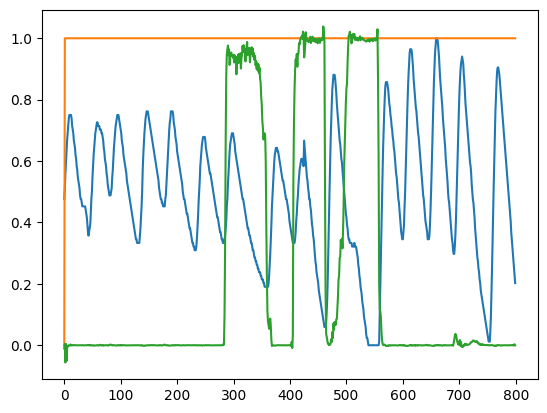

0.00048933557


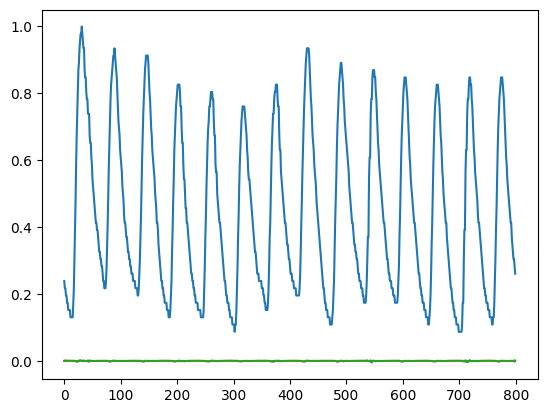

0.68839943


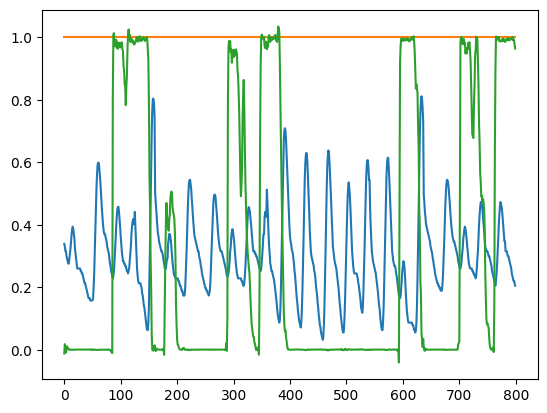

0.83847725


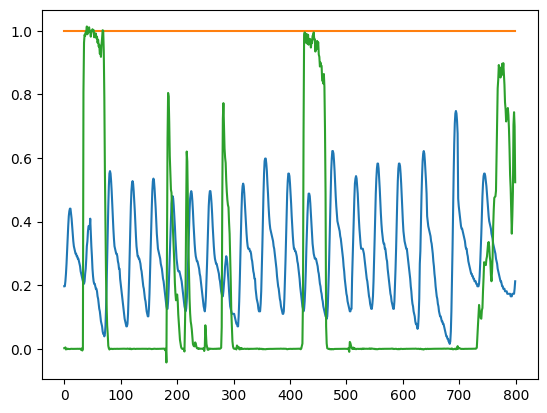

0.0009798429


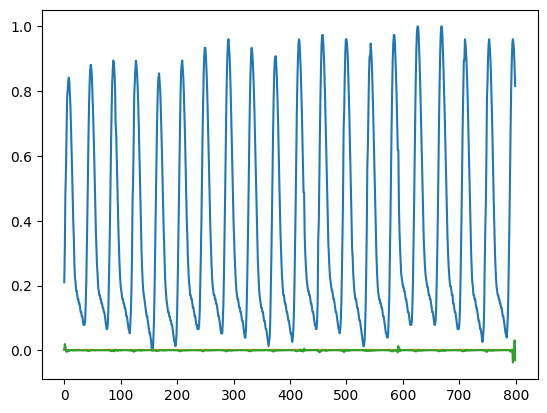

0.0071843574


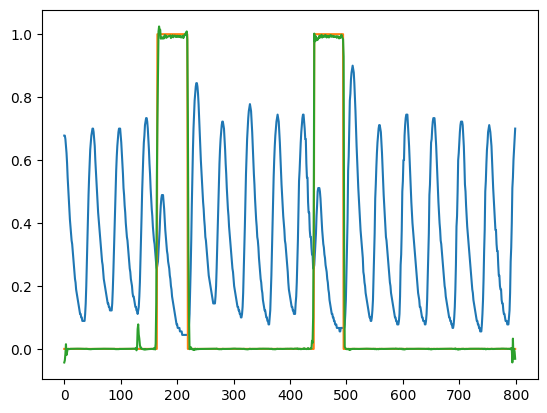

0.018484656


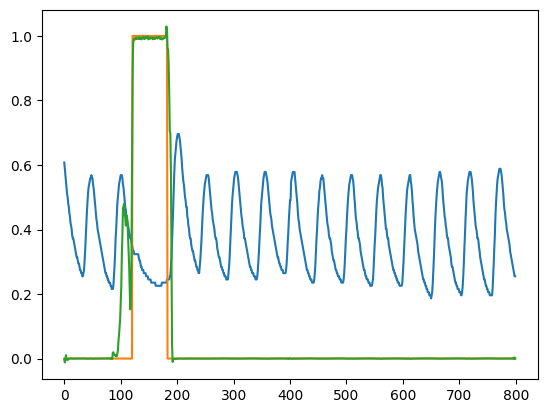

0.0022744008


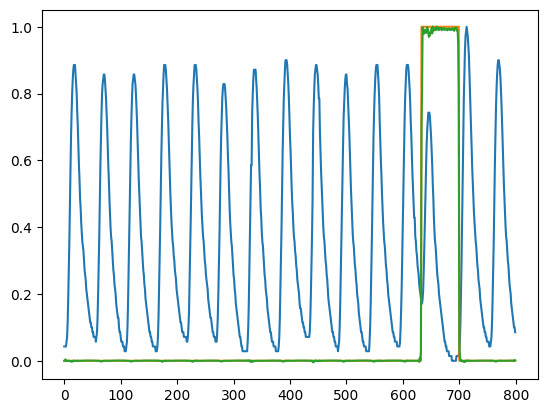

0.7164803


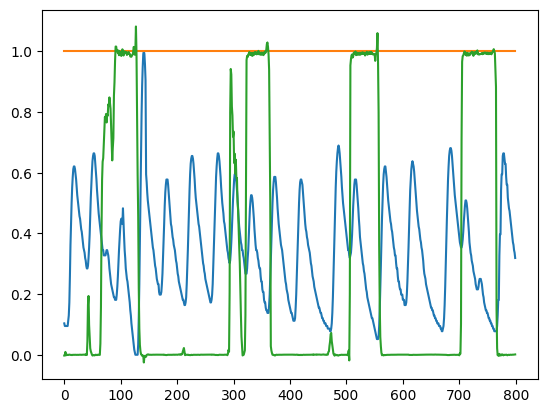

0.7353636


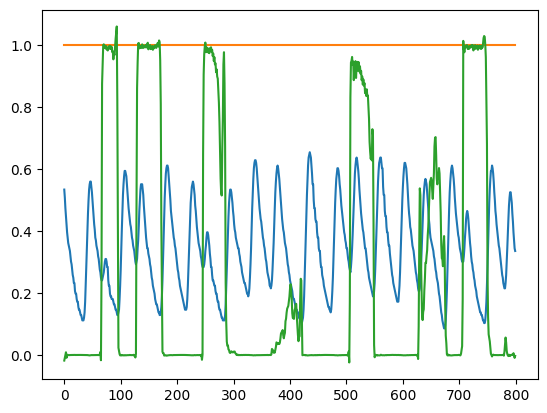

0.016526667


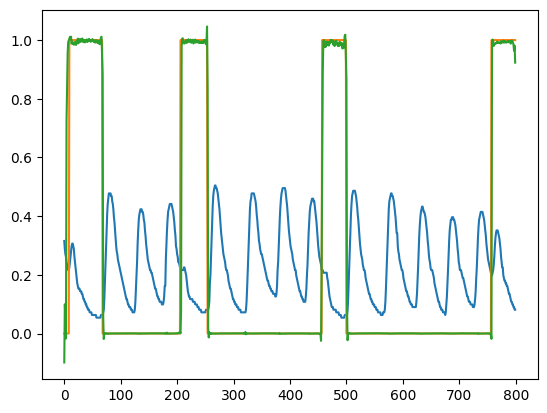

0.03976157


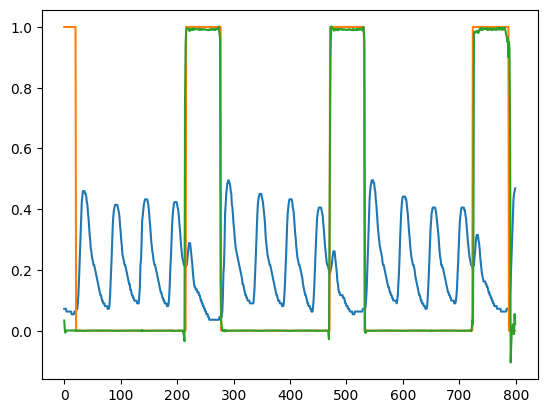

0.04115652


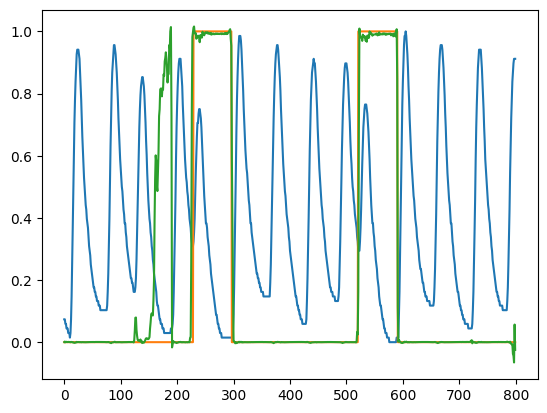

0.0009913273


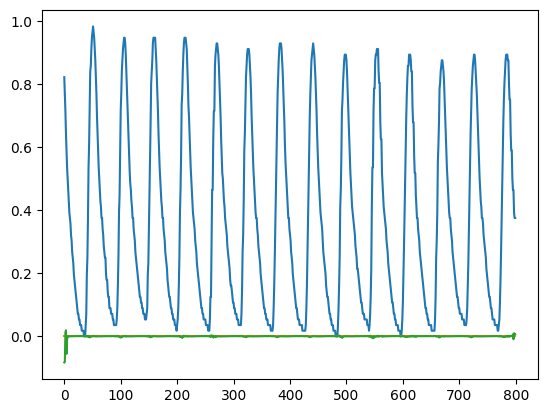

0.0006655623


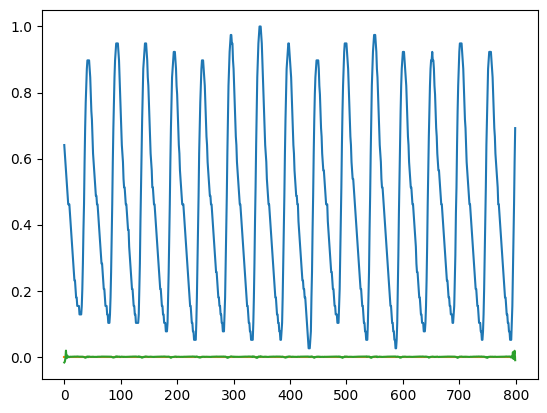

0.0004960959


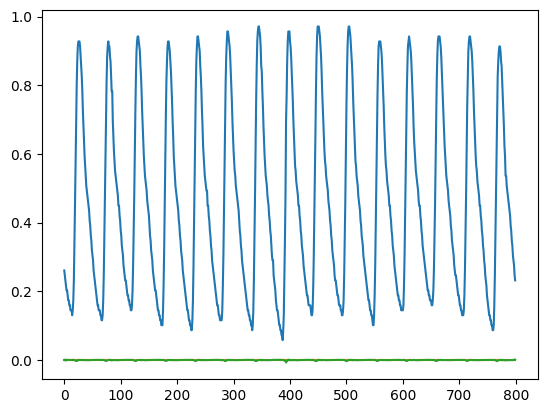

0.6123051


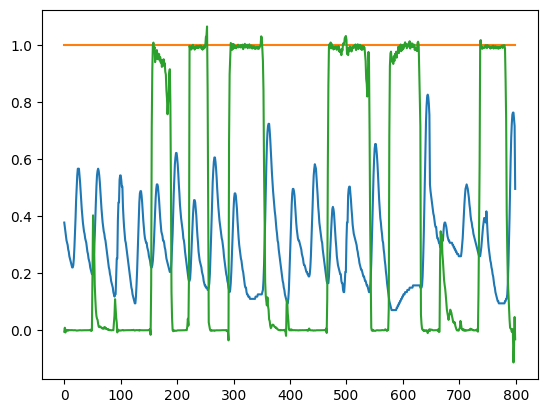

0.55075324


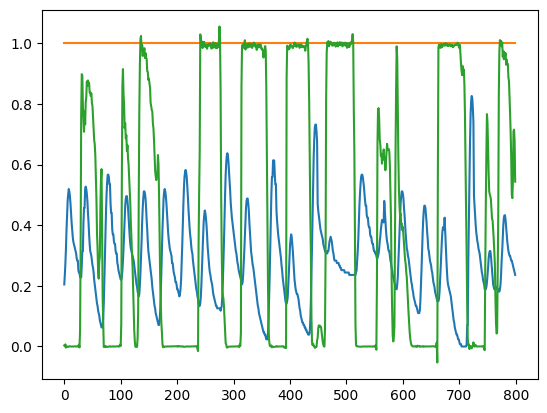

0.005227698


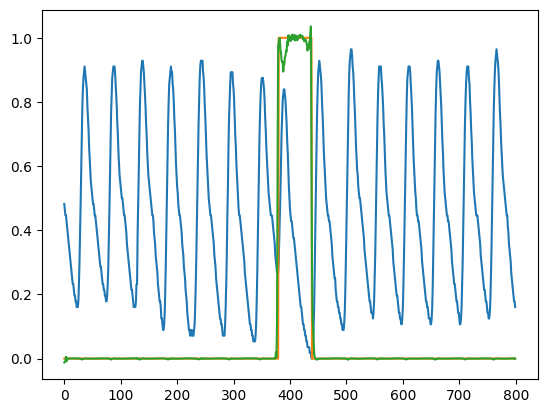

0.92236555


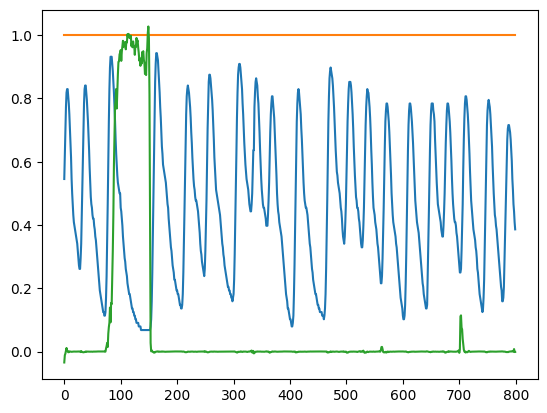

0.7439711


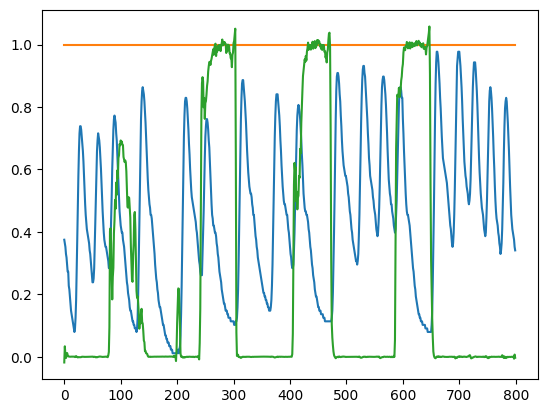

0.99491173


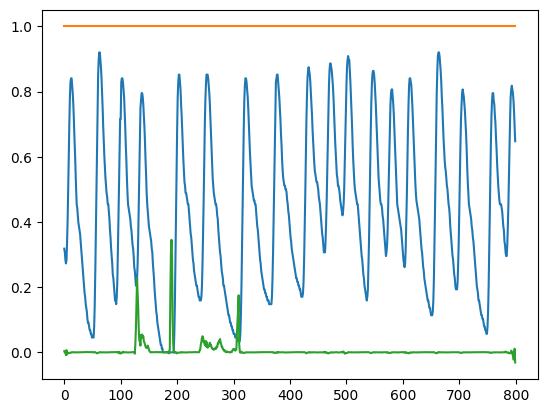

0.017150113


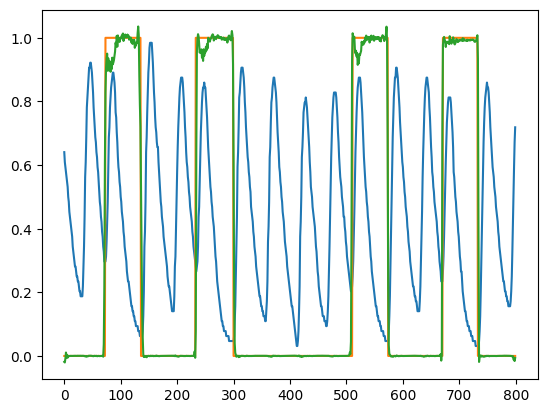

0.374112


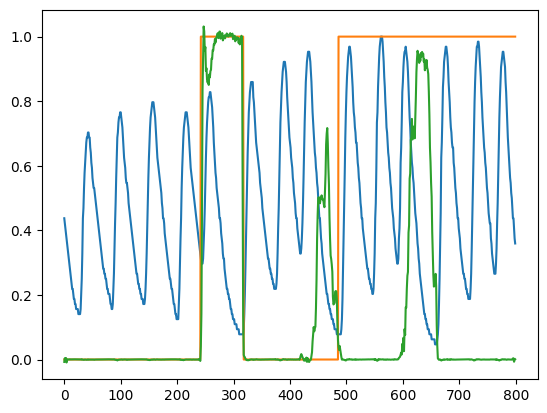

0.024100065


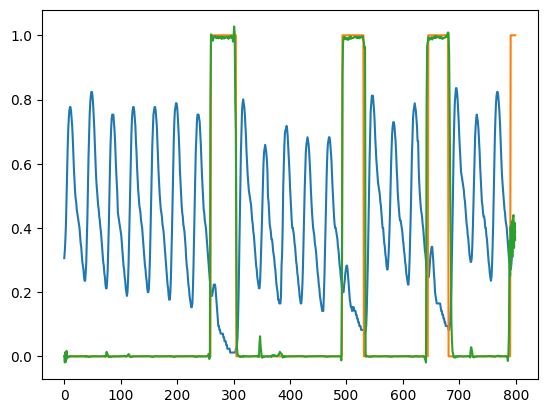

0.1410768


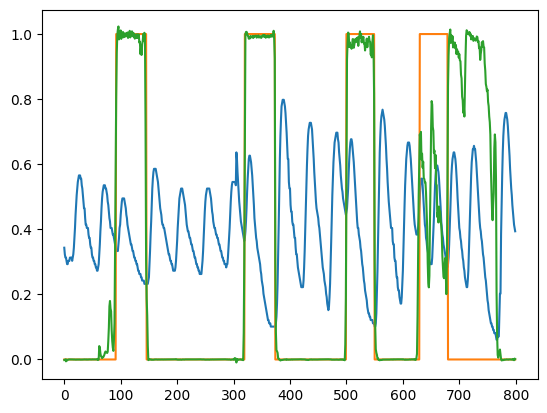

0.0009711237


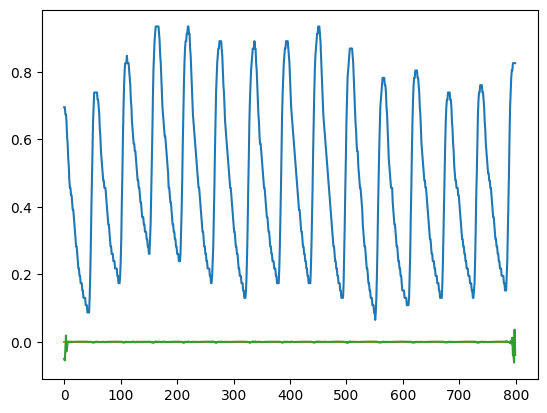

0.73375434


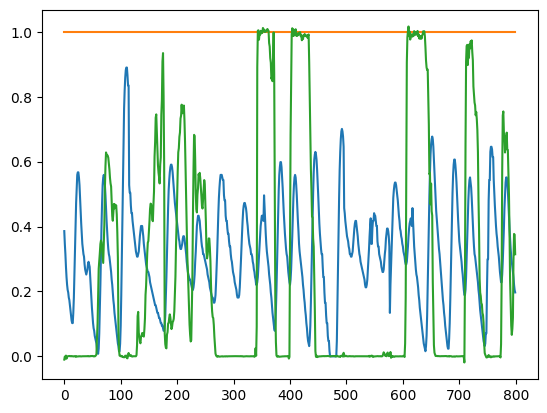

0.21495284


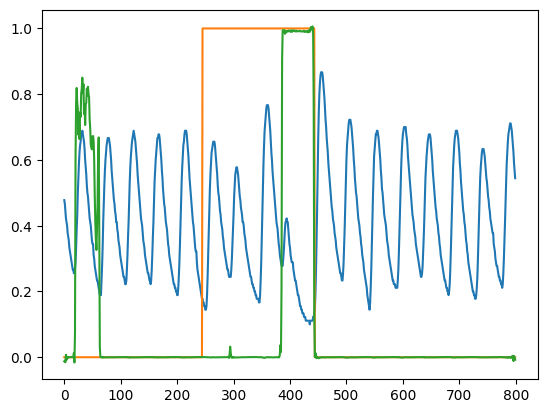

0.3005206


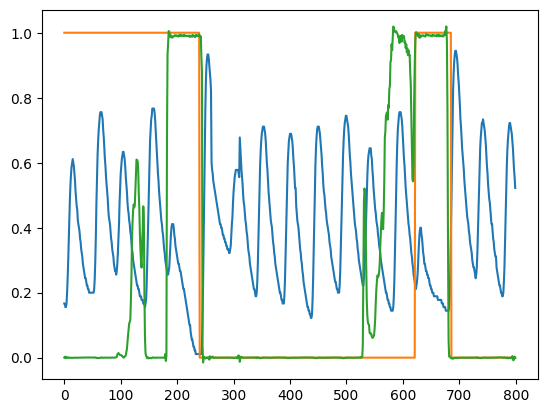

0.014765522


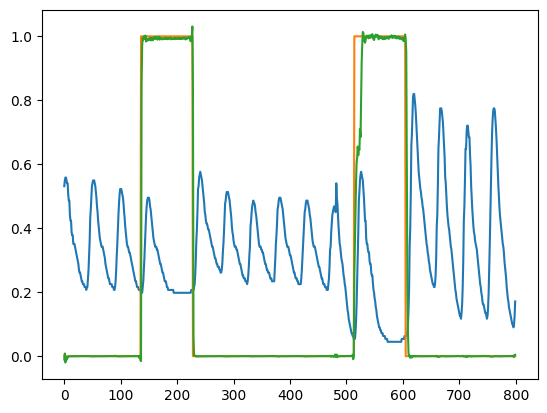

0.0072258096


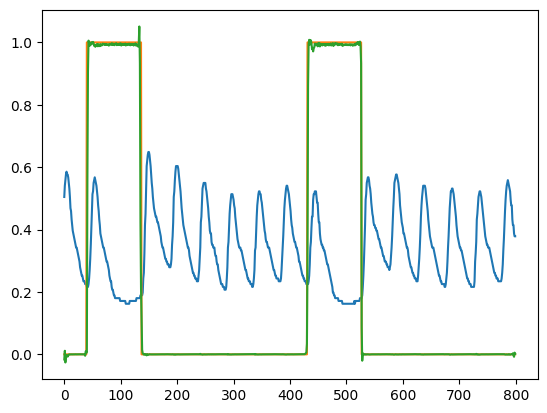

0.011073335


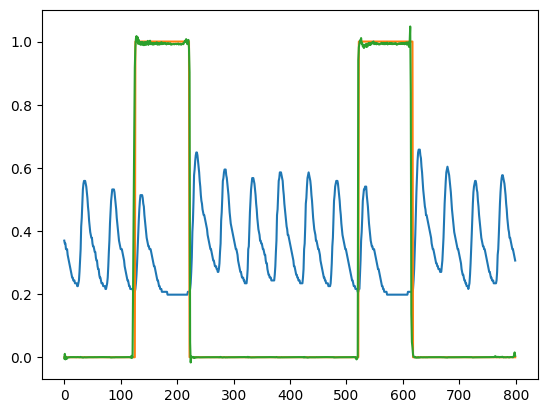

0.003272543


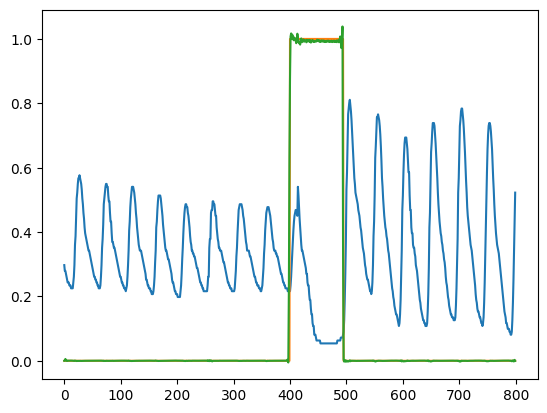

0.07784734


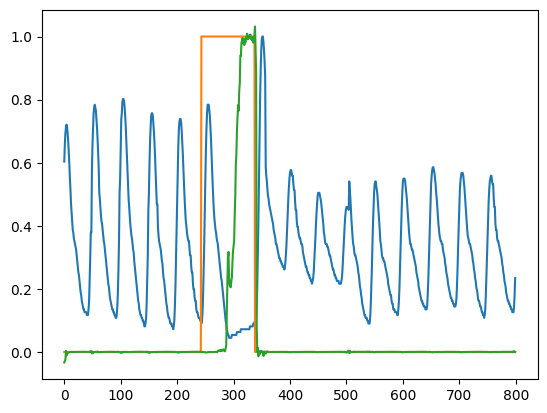

0.81334877


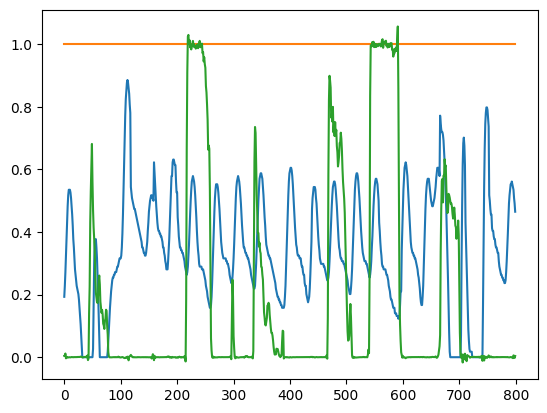

0.69996184


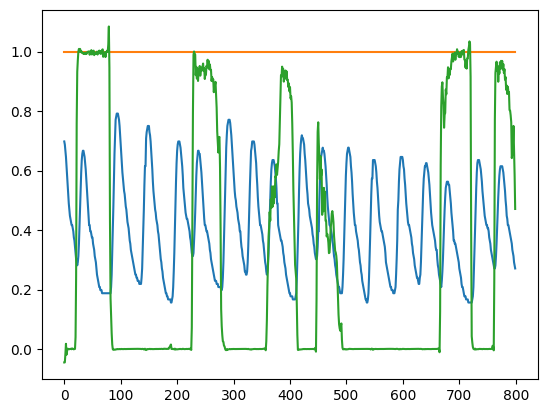

0.9596141


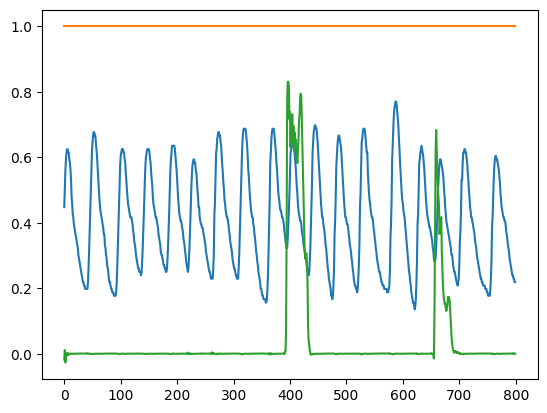

1.0000085


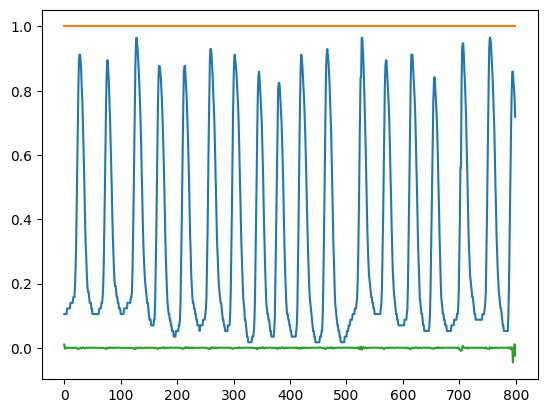

0.108972855


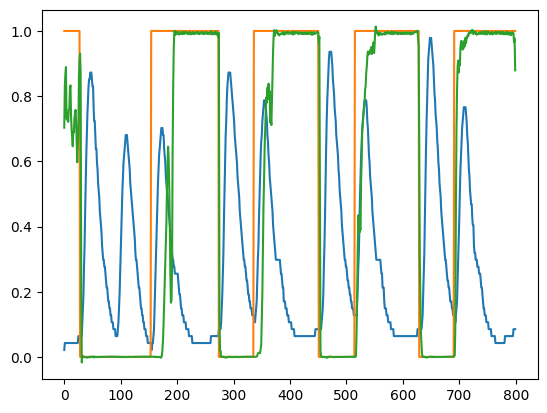

0.10255727


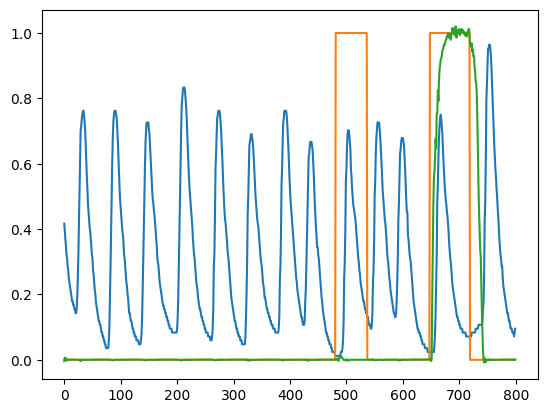

0.7703145


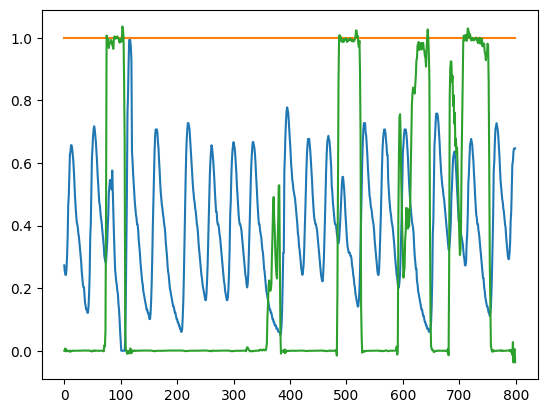

0.82611537


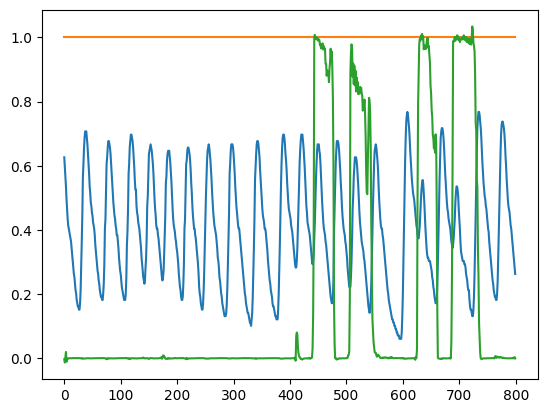

0.00643251


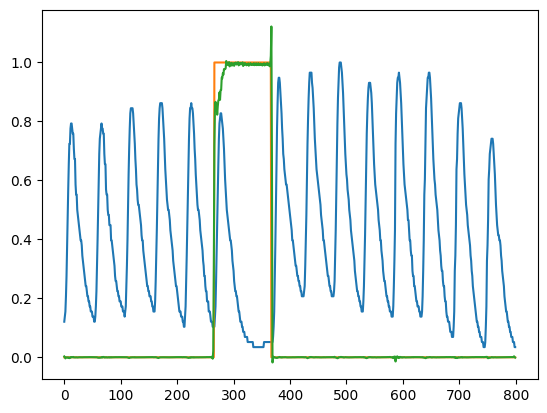

0.021658437


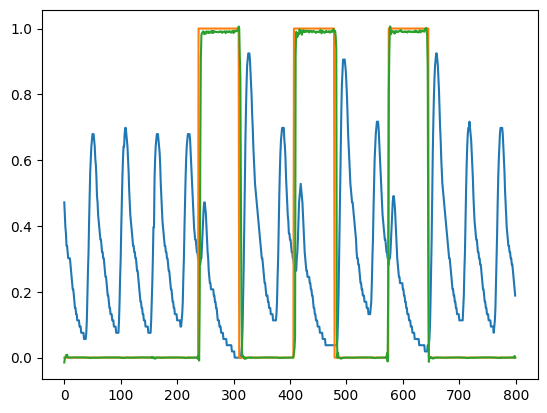

In [9]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()